<a href="https://colab.research.google.com/github/badrmellal/kitti_omu_mae/blob/main/kitti_pretrain_omumae_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# OMU-MAE

This notebook trains and evaluates **four use cases** in a single run:

| variant   | architecture                           | pretraining objective                          |
|-----------|----------------------------------------|------------------------------------------------|
| `random`  | OMU-MAE class (architecture-matched)    | none — fresh init, used as probe baseline       |
| `occmae`  | `OccupancyMAEBaseline` (LiDAR-only, dense 3D CNN) | range-aware mask + focal BCE on occupancy |
| `nomask`  | OMU-MAE class (unchanged)               | mask_ratio=0; cross-modal feature regression at all positions (CleverDistiller-equivalent) |
| `full`    | OMU-MAE class (unchanged)               | mask=0.85 + dual reconstruction (current method)            |

The probe protocol is identical across all four (frozen encoder + 1×1×1 conv probe on bottleneck features).

**Hardware target.** This notebook is configured for CUDA RTX 5080 (16 GB). It auto-detects MPS / CPU as fallback.

**Outputs.** Each variant saves to `data/runs/kitti_omumae_full/{variant}/`. The final comparison plot and `final_results.json` go to `data/runs/kitti_omumae_full/`.


## 1. Setup


Download KITTI + SemanticKITTI datasets

 This cell downloads everything the notebook needs:
  * hocop1/kitti-odometry : 22 sequences of left-camera images, Velodyne LiDAR, calib
  * luischavarriazamora/semantickitti : per-point class labels


In [ ]:
import os, sys, glob, shutil
from pathlib import Path

ON_COLAB  = 'google.colab' in sys.modules
ON_KAGGLE = ('KAGGLE_KERNEL_RUN_TYPE' in os.environ
             or 'KAGGLE_URL_BASE' in os.environ)

if ON_KAGGLE:
    # Add via "+ Add Data": hocop1/kitti-odometry  AND  luischavarriazamora/semantickitti
    kitti_path = '/kaggle/input/kitti-odometry'
    sk_path    = '/kaggle/input/semantickitti'
    for p in (kitti_path, sk_path):
        assert os.path.exists(p), f'Missing {p}. Add datasets via "+ Add Data" panel.'
else:
    get_ipython().system('pip install -q kagglehub')
    import kagglehub
    if ON_COLAB and not (Path.home() / '.kaggle/kaggle.json').exists():
        print('Upload kaggle.json (https://www.kaggle.com/settings/account → API tokens → scroll down to Create Legacy API Key)')
        from google.colab import files
        up = files.upload()
        kj = Path.home() / '.kaggle/kaggle.json'
        kj.parent.mkdir(exist_ok=True); kj.write_bytes(up['kaggle.json']); os.chmod(kj, 0o600)
    print('Downloading KITTI odometry...');  kitti_path = kagglehub.dataset_download('hocop1/kitti-odometry')
    print('Downloading SemanticKITTI labels...'); sk_path  = kagglehub.dataset_download('luischavarriazamora/semantickitti')

DATA = Path.cwd() / 'data'; DATA.mkdir(exist_ok=True)
for src, name in [(kitti_path, 'kitti_odometry'), (sk_path, 'semantickitti')]:
    dst = DATA / name
    if dst.is_symlink(): dst.unlink()
    elif dst.exists():   shutil.rmtree(dst)
    dst.symlink_to(src)

n_img = len(glob.glob(str(DATA / '**/image_2/*.png'), recursive=True))
n_bin = len(glob.glob(str(DATA / '**/velodyne/*.bin'), recursive=True))
n_lbl = len(glob.glob(str(DATA / '**/labels/*.label'), recursive=True))
print(f'[OK] images={n_img:,}  velodyne={n_bin:,}  labels={n_lbl:,}  ->  {DATA}')
assert n_img > 1000 and n_bin > 1000 and n_lbl > 1000, 'Download incomplete'

Upload kaggle.json (https://www.kaggle.com/settings/account → API tokens → scroll down to Create Legacy API Key)


KeyboardInterrupt: 

In [ ]:

import os, sys, glob, time, json, csv, math, random
from pathlib import Path
from copy import deepcopy
from itertools import islice

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Deterministic seeding + device detection (CUDA-first; MPS / CPU fallback)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def best_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')

device = best_device()
IS_CUDA = device.type == 'cuda'
IS_MPS = device.type == 'mps'

if IS_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False  # benchmark > determinism for speed
    torch.backends.cudnn.benchmark = True
    print(f'device: cuda ({torch.cuda.get_device_name(0)})')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'  cuDNN: {torch.backends.cudnn.version()}  benchmark=True')
elif IS_MPS:
    if hasattr(torch.mps, 'manual_seed'):
        torch.mps.manual_seed(SEED)
    print(f'device: mps')
else:
    print(f'device: cpu (no GPU detected — training will be SLOW)')

seed_generator = torch.Generator()
seed_generator.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

ROOT = Path.cwd()
OUT_BASE = ROOT / 'data' / 'runs' / 'kitti_omumae_full'
OUT_BASE.mkdir(parents=True, exist_ok=True)
print(f'\nartifacts → {OUT_BASE}')


device: cpu (no GPU detected — training will be SLOW)

artifacts → /content/data/runs/kitti_omumae_full


## 2. Configuration


In [ ]:

# CUDA-tuned config (auto-falls-back on MPS/CPU)
CFG = {
    'data': {
        'image_size': 224,
        'voxel_resolution': [0.4, 0.4, 0.4],     # m per voxel
        'voxel_grid_size': [128, 128, 32],        # X * Y * Z
        'n_points': 16384,
        'n_samples': 8000,
    },
    'mask': {
        'mask_ratio': 0.85,
        'range_aware': True,
        'range_decay': 0.5,
    },
    'model': {
        'feat_dim': 64,
        'image_feat_dim': 384,
        'use_dinov2': True,
        'dinov2_model': 'dinov2_vits14',
    },
    'train': {
        'batch_size': 4 if IS_CUDA else 2,
        'num_workers': 4 if IS_CUDA else 0,
        'pin_memory': IS_CUDA,
        'persistent_workers': IS_CUDA,
        'n_steps': 5000,
        'log_every': 50,
        'lr': 5e-4,
        'weight_decay': 0.05,
        'lambda_occ': 1.0,
        'lambda_feat': 0.5,
        'grad_clip': 1.0,
        # focal-loss coefficients (used by Occupancy-MAE baseline)
        'focal_alpha': 0.25,
        'focal_gamma': 2.0,
    },
}
GRID = tuple(CFG['data']['voxel_grid_size'])
print(f'voxel grid: {GRID}  ({GRID[0]*GRID[1]*GRID[2]:,} voxels)')
print(f'batch_size: {CFG["train"]["batch_size"]}, num_workers: {CFG["train"]["num_workers"]}')
print(f'n_steps: {CFG["train"]["n_steps"]}')


voxel grid: (128, 128, 32)  (524,288 voxels)
batch_size: 2, num_workers: 0
n_steps: 5000


## 3. Data indexing

Sequence-aware keys; image-2 only; random shuffle before capping for diversity.


In [ ]:

KITTI_ROOT = ROOT / 'data'
N_SAMPLES = CFG['data']['n_samples']
if not KITTI_ROOT.exists():
    raise FileNotFoundError(f'KITTI_ROOT={KITTI_ROOT} not found.')

def seq_stem_key(path):
    parts = Path(path).parts
    for i, p in enumerate(parts):
        if p == 'sequences' and i + 1 < len(parts):
            return (parts[i + 1], Path(path).stem)
    return ('unknown', str(Path(path).resolve()))

img_paths = sorted(glob.glob(str(KITTI_ROOT / '**' / 'image_2' / '*.png'), recursive=True))
img_paths += sorted(glob.glob(str(KITTI_ROOT / '**' / 'image_2' / '*.jpg'), recursive=True))
bin_paths = sorted(glob.glob(str(KITTI_ROOT / '**' / 'velodyne' / '*.bin'), recursive=True))
lbl_paths = sorted(glob.glob(str(KITTI_ROOT / '**' / 'labels'   / '*.label'), recursive=True))

img_by = {seq_stem_key(p): p for p in img_paths}
bin_by = {seq_stem_key(p): p for p in bin_paths}
lbl_by = {seq_stem_key(p): p for p in lbl_paths}
common = sorted(set(img_by) & set(bin_by))
print(f'matched (all sequences): {len(common):,}')

_rng_idx = np.random.RandomState(SEED)
_perm = _rng_idx.permutation(len(common))
common_capped = sorted([common[i] for i in _perm[:N_SAMPLES]])

samples = [{'seq': k[0], 'stem': k[1], 'img': img_by[k], 'bin': bin_by[k],
            'label': lbl_by.get(k)} for k in common_capped]

seq_counts = {}
for s in samples:
    seq_counts[s['seq']] = seq_counts.get(s['seq'], 0) + 1
print(f'sequences in selected: {len(seq_counts)}')
print(f'top sequences: {sorted(seq_counts.items(), key=lambda kv: -kv[1])[:5]}')
assert len(seq_counts) >= 10, f'Expected >=10 sequences, got {len(seq_counts)}'


matched (all sequences): 0
sequences in selected: 0
top sequences: []


AssertionError: Expected >=10 sequences, got 0

## 4. KITTI calibration parser


In [ ]:

def parse_kitti_calib(calib_path):
    out = {}
    with open(calib_path) as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, vals = line.split(':', 1)
            arr = np.array([float(v) for v in vals.split()], dtype=np.float32)
            if arr.size == 12:
                out[key.strip()] = arr.reshape(3, 4)
    return out

calib_cache = {}
for s in samples:
    seq = s['seq']
    if seq in calib_cache:
        continue
    img_dir = Path(s['img']).parent
    calib_path = img_dir.parent / 'calib.txt'
    if calib_path.exists():
        try:
            calib_cache[seq] = parse_kitti_calib(calib_path)
        except Exception:
            pass

samples = [s for s in samples if s['seq'] in calib_cache]
print(f'samples with calibration: {len(samples)} / {len(common_capped)}')
print(f'sequences with calibration: {len(calib_cache)}')


samples with calibration: 8000 / 8000
sequences with calibration: 22


## 5. Frozen DINOv2 image encoder


In [ ]:

class FrozenImageEncoder(nn.Module):
    """Frozen DINOv2 ViT-S/14. Returns per-patch tokens."""
    def __init__(self, model_name='dinov2_vits14', use_dinov2=True):
        super().__init__()
        self.embed_dim = 384
        self.patch_grid = 16              # 224 / 14 = 16
        self.using_dinov2 = False
        if use_dinov2:
            try:
                self.backbone = torch.hub.load('facebookresearch/dinov2', model_name,
                                                pretrained=True, trust_repo=True)
                self.using_dinov2 = True
                print(f'[OK] loaded DINOv2 {model_name}')
            except Exception as e:
                print(f'[WARN] DINOv2 load failed ({e}); using random ViT-S/14 fallback.')
        if not self.using_dinov2:
            try:
                import timm
                self.backbone = timm.create_model('vit_small_patch14_dinov2', pretrained=False)
            except Exception:
                self.backbone = None
                print('[WARN] no timm fallback; image features will be zero-vectors.')
        if self.backbone is not None:
            for p in self.backbone.parameters():
                p.requires_grad_(False)
            self.backbone.eval()

    @torch.no_grad()
    def forward(self, image):
        """image: (B, 3, 224, 224) -> (B, N_patches, D)"""
        if self.backbone is None:
            B = image.shape[0]
            return torch.zeros(B, self.patch_grid * self.patch_grid, self.embed_dim,
                                device=image.device)
        if self.using_dinov2:
            out = self.backbone.forward_features(image)
            tokens = out['x_norm_patchtokens'] if isinstance(out, dict) else out
        else:
            tokens = self.backbone.forward_features(image)
            if tokens.dim() == 3 and tokens.shape[1] > self.patch_grid ** 2:
                tokens = tokens[:, 1:]   # drop cls
        return tokens

img_encoder = FrozenImageEncoder(CFG['model']['dinov2_model'],
                                  CFG['model']['use_dinov2']).to(device)
print(f'patch grid: {img_encoder.patch_grid}x{img_encoder.patch_grid}, '
      f'embed_dim: {img_encoder.embed_dim}')


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 128MB/s]


[OK] loaded DINOv2 dinov2_vits14
patch grid: 16x16, embed_dim: 384


## 6. Dataset

A single dataset class is used for all 4 variants. The variant flag determines
whether DINOv2 features are computed; for `occmae` the features are skipped
entirely (truly LiDAR-only).


In [ ]:

class KittiOMUMAE(Dataset):
    def __init__(self, samples, calib_cache, image_size=224, n_points=16384):
        self.samples = samples
        self.calib_cache = calib_cache
        self.image_size = image_size
        self.n_points = n_points

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_pil = Image.open(s['img']).convert('RGB')
        W_orig, H_orig = img_pil.size
        img_pil = img_pil.resize((self.image_size, self.image_size))
        img = np.asarray(img_pil).astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std
        img = np.transpose(img, (2, 0, 1))

        pts = np.fromfile(s['bin'], dtype=np.float32).reshape(-1, 4)
        if pts.shape[0] >= self.n_points:
            sel = np.random.choice(pts.shape[0], self.n_points, replace=False)
            pts = pts[sel]
        else:
            pad = np.zeros((self.n_points - pts.shape[0], 4), dtype=np.float32)
            pts = np.concatenate([pts, pad], axis=0)

        cal = self.calib_cache[s['seq']]
        sx = self.image_size / W_orig
        sy = self.image_size / H_orig
        S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], dtype=np.float32)
        P2_scaled = (S @ cal['P2']).astype(np.float32)
        Tr = cal['Tr'].astype(np.float32)

        return {
            'image':  torch.from_numpy(img.astype(np.float32)),
            'points': torch.from_numpy(pts),
            'P2':     torch.from_numpy(P2_scaled),
            'Tr':     torch.from_numpy(Tr),
            'seq':    s['seq'],
            'stem':   s['stem'],
        }

def collate(batch):
    return {
        'image':  torch.stack([b['image']  for b in batch]),
        'points': torch.stack([b['points'] for b in batch]),
        'P2':     torch.stack([b['P2']     for b in batch]),
        'Tr':     torch.stack([b['Tr']     for b in batch]),
    }

n_val = max(64, len(samples) // 10)
train_samples = samples[:-n_val]
val_samples   = samples[-n_val:]
train_ds = KittiOMUMAE(train_samples, calib_cache, CFG['data']['image_size'],
                        CFG['data']['n_points'])
val_ds   = KittiOMUMAE(val_samples,   calib_cache, CFG['data']['image_size'],
                        CFG['data']['n_points'])
print(f'train={len(train_ds)}  val={len(val_ds)}')


NameError: name 'calib_cache' is not defined

## 7. Voxelization (cross-modal and LiDAR-only)


In [ ]:

def voxelize_lidar_only(points, grid_size, voxel_size):
    """
    Args:
        points: (B, N, 4)
    Returns:
        occ: (B, 1, X, Y, Z) binary occupancy
    """
    B, N = points.shape[0], points.shape[1]
    X, Y, Z = grid_size
    vx, vy, vz = voxel_size
    ox = X * vx / 2; oy = Y * vy / 2; oz = Z * vz / 2

    pts = points[..., :3]
    ix = ((pts[..., 0] + ox) / vx).long().clamp(0, X - 1)
    iy = ((pts[..., 1] + oy) / vy).long().clamp(0, Y - 1)
    iz = ((pts[..., 2] + oz) / vz).long().clamp(0, Z - 1)

    occ = torch.zeros(B, 1, X, Y, Z, device=points.device)
    bidx = torch.arange(B, device=points.device).unsqueeze(-1).expand(-1, N)
    occ[bidx, 0, ix, iy, iz] = 1.0
    return occ


def voxelize_with_feats(points, dino_feats, P2, Tr, grid_size, voxel_size,
                         image_size, patch_grid):
    """
    Cross-modal voxelization: occupancy + per-voxel mean-pooled DINOv2 patch features
    (projected via camera-LiDAR calibration).

    Returns:
        occ:  (B, 1, X, Y, Z)
        feat: (B, D, X, Y, Z)
    """
    B, N = points.shape[0], points.shape[1]
    X, Y, Z = grid_size
    vx, vy, vz = voxel_size
    ox = X * vx / 2; oy = Y * vy / 2; oz = Z * vz / 2
    D = dino_feats.shape[-1]

    pts = points[..., :3]
    ix = ((pts[..., 0] + ox) / vx).long().clamp(0, X - 1)
    iy = ((pts[..., 1] + oy) / vy).long().clamp(0, Y - 1)
    iz = ((pts[..., 2] + oz) / vz).long().clamp(0, Z - 1)

    occ = torch.zeros(B, 1, X, Y, Z, device=points.device)
    feat = torch.zeros(B, D, X, Y, Z, device=points.device)
    cnt  = torch.zeros(B, 1, X, Y, Z, device=points.device)

    bidx = torch.arange(B, device=points.device).unsqueeze(-1).expand(-1, N)
    occ[bidx, 0, ix, iy, iz] = 1.0

    # Project to camera (rectified left)
    pts_h = torch.cat([pts, torch.ones(B, N, 1, device=pts.device)], dim=-1)  # (B,N,4)
    cam = (Tr @ pts_h.transpose(1, 2)).transpose(1, 2)                         # (B,N,3)
    cam_h = torch.cat([cam, torch.ones(B, N, 1, device=pts.device)], dim=-1)
    img_xy = (P2 @ cam_h.transpose(1, 2)).transpose(1, 2)                      # (B,N,3)
    in_front = img_xy[..., 2] > 0.1
    u = (img_xy[..., 0] / img_xy[..., 2].clamp(min=1e-3)).long()
    v = (img_xy[..., 1] / img_xy[..., 2].clamp(min=1e-3)).long()
    in_image = (u >= 0) & (u < image_size) & (v >= 0) & (v < image_size)
    valid = in_front & in_image

    pu = (u.float() / image_size * patch_grid).long().clamp(0, patch_grid - 1)
    pv = (v.float() / image_size * patch_grid).long().clamp(0, patch_grid - 1)
    patch_idx = (pv * patch_grid + pu).clamp(0, patch_grid * patch_grid - 1)

    # Gather DINO features per point
    f_pt = torch.gather(dino_feats, 1, patch_idx.unsqueeze(-1).expand(-1, -1, D))
    f_pt = f_pt * valid.unsqueeze(-1).float()

    # Scatter-add to voxels (mean pool)
    for b in range(B):
        if valid[b].sum() == 0:
            continue
        idx_v = (ix[b] * Y * Z + iy[b] * Z + iz[b])  # flat voxel index
        # use index_add for atomic-like per-voxel accumulation
        flat_feat = feat[b].permute(1, 2, 3, 0).reshape(-1, D)  # (X*Y*Z, D)
        flat_cnt  = cnt[b].permute(1, 2, 3, 0).reshape(-1, 1)
        flat_feat.index_add_(0, idx_v, f_pt[b])
        flat_cnt.index_add_(0, idx_v, valid[b].unsqueeze(-1).float())
        feat[b] = flat_feat.reshape(X, Y, Z, D).permute(3, 0, 1, 2)
        cnt[b]  = flat_cnt.reshape(X, Y, Z, 1).permute(3, 0, 1, 2)

    feat = feat / cnt.clamp(min=1.0)
    return occ, feat


## 8. Range-aware masking


In [ ]:

def build_voxel_mask(grid_size, voxel_size, mask_ratio=0.85, range_decay=0.5,
                      device='cpu', batch_size=1):
    """Range-aware random mask. Closer voxels are masked at higher rate."""
    X, Y, Z = grid_size
    vx, vy, vz = voxel_size
    ox = X * vx / 2; oy = Y * vy / 2; oz = Z * vz / 2

    xs = torch.arange(X, device=device).float() * vx - ox + vx / 2
    ys = torch.arange(Y, device=device).float() * vy - oy + vy / 2
    zs = torch.arange(Z, device=device).float() * vz - oz + vz / 2
    grid_x, grid_y, grid_z = torch.meshgrid(xs, ys, zs, indexing='ij')
    dist = torch.sqrt(grid_x ** 2 + grid_y ** 2 + grid_z ** 2)

    if range_decay > 0:
        prob = mask_ratio / (1.0 + range_decay * dist)
    else:
        prob = torch.full_like(dist, mask_ratio)
    prob = prob.clamp(0.0, 1.0)

    mask_list = []
    for _ in range(batch_size):
        m = (torch.rand_like(prob) < prob).float()
        mask_list.append(m)
    mask = torch.stack(mask_list, dim=0).unsqueeze(1)  # (B, 1, X, Y, Z)
    return mask


## 9. Models

* `OMUMAE` full cross-modal voxel MAE (used by `nomask`, `full`, and `random` baseline).
* `OccupancyMAEBaseline` Truly LiDAR-only architecture: 2-channel input
  (occupancy + mask indicator), dense 3D CNN encoder/decoder, single occupancy head.
  Faithful re-implementation of Occupancy-MAE's training recipe within our dense 3D CNN.


In [ ]:

def conv_bn_act(in_ch, out_ch, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv3d(in_ch, out_ch, k, stride=s, padding=p, bias=False),
        nn.GroupNorm(8, out_ch),
        nn.GELU(),
    )

def upsample_conv(in_ch, out_ch):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
        nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.GroupNorm(8, out_ch),
        nn.GELU(),
    )


class OMUMAE(nn.Module):
    """Cross-modal voxel MAE.  Input: 1 (occ) + D (DINO feat) + 1 (mask indicator)."""
    def __init__(self, image_feat_dim=384, hidden=64):
        super().__init__()
        in_ch = 1 + image_feat_dim + 1
        self.image_feat_dim = image_feat_dim
        self.in_proj = nn.Conv3d(in_ch, hidden, 1)

        self.enc = nn.Sequential(
            conv_bn_act(hidden, hidden),
            conv_bn_act(hidden, hidden * 2, s=2),
            conv_bn_act(hidden * 2, hidden * 2),
            conv_bn_act(hidden * 2, hidden * 4, s=2),
            conv_bn_act(hidden * 4, hidden * 4),
        )
        self.dec = nn.Sequential(
            conv_bn_act(hidden * 4, hidden * 4),
            upsample_conv(hidden * 4, hidden * 2),
            conv_bn_act(hidden * 2, hidden * 2),
            upsample_conv(hidden * 2, hidden),
            conv_bn_act(hidden, hidden),
        )
        self.head_occ  = nn.Conv3d(hidden, 1, 1)
        self.head_feat = nn.Conv3d(hidden, image_feat_dim, 1)

    def encode(self, occ, feat, mask=None):
        if mask is not None:
            occ_in = occ * (1 - mask)
            feat_in = feat * (1 - mask)
            mind = mask
        else:
            occ_in, feat_in = occ, feat
            mind = torch.zeros_like(occ)
        x = torch.cat([occ_in, feat_in, mind], dim=1)
        x = self.in_proj(x)
        h = self.enc(x)
        return h

    def forward(self, occ, feat, mask):
        h = self.encode(occ, feat, mask)
        d = self.dec(h)
        occ_logit = self.head_occ(d)
        feat_pred = self.head_feat(d)
        return occ_logit, feat_pred


class OccupancyMAEBaseline(nn.Module):
    """Faithful Occupancy-MAE re-implementation: truly LiDAR-only, single-head.

    Input: 1 (occ) + 1 (mask indicator)  NO DINOv2 features.
    Output: occupancy logit only.
    Same dense 3D CNN architecture as OMU-MAE so probe protocol is identical.
    """
    def __init__(self, hidden=64):
        super().__init__()
        in_ch = 1 + 1
        self.in_proj = nn.Conv3d(in_ch, hidden, 1)
        self.enc = nn.Sequential(
            conv_bn_act(hidden, hidden),
            conv_bn_act(hidden, hidden * 2, s=2),
            conv_bn_act(hidden * 2, hidden * 2),
            conv_bn_act(hidden * 2, hidden * 4, s=2),
            conv_bn_act(hidden * 4, hidden * 4),
        )
        self.dec = nn.Sequential(
            conv_bn_act(hidden * 4, hidden * 4),
            upsample_conv(hidden * 4, hidden * 2),
            conv_bn_act(hidden * 2, hidden * 2),
            upsample_conv(hidden * 2, hidden),
            conv_bn_act(hidden, hidden),
        )
        self.head_occ = nn.Conv3d(hidden, 1, 1)

    def encode(self, occ, feat=None, mask=None):
        # `feat` argument accepted for interface parity with OMUMAE but ignored.
        if mask is not None:
            occ_in = occ * (1 - mask)
            mind = mask
        else:
            occ_in = occ
            mind = torch.zeros_like(occ)
        x = torch.cat([occ_in, mind], dim=1)
        x = self.in_proj(x)
        h = self.enc(x)
        return h

    def forward(self, occ, mask):
        h = self.encode(occ, mask=mask)
        d = self.dec(h)
        occ_logit = self.head_occ(d)
        return occ_logit


## 10. Losses (OMU-MAE dual + Occupancy-MAE focal)


In [ ]:

def omumae_loss(occ_logit, feat_pred, occ_true, feat_true, mask,
                lambda_occ=1.0, lambda_feat=0.5):
    """Dual reconstruction loss for OMU-MAE (BCE on masked occ + MSE on masked-occupied feat).
    If mask is all zeros (mask_ratio=0 case), both losses become unmasked global losses."""
    if mask.sum() == 0:
        # CleverDistiller-equivalent regime: regress at all positions
        m_eff = torch.ones_like(mask)
    else:
        m_eff = mask
    m_f = m_eff.float()

    # Occupancy loss (BCE with positive-class re-weighting)
    pos = (occ_true * m_f).sum().clamp(min=1.0)
    neg = ((1.0 - occ_true) * m_f).sum().clamp(min=1.0)
    pos_weight = neg / pos
    bce = F.binary_cross_entropy_with_logits(
        occ_logit, occ_true, reduction='none', pos_weight=pos_weight)
    L_occ = (bce * m_f).sum() / m_f.sum().clamp(min=1.0)

    # Feature loss: MSE at masked-and-occupied (sparse indexing — memory friendly)
    mo_bool = m_eff.squeeze(1).bool() & occ_true.squeeze(1).bool()
    n_mo = mo_bool.sum()
    if n_mo > 0:
        idx = mo_bool.nonzero(as_tuple=True)
        f_p = feat_pred[idx[0], :, idx[1], idx[2], idx[3]]
        f_t = feat_true[idx[0], :, idx[1], idx[2], idx[3]]
        L_feat = F.mse_loss(f_p, f_t)
    else:
        L_feat = feat_pred.new_zeros(())

    total = lambda_occ * L_occ + lambda_feat * L_feat
    return total, {'L_occ': L_occ, 'L_feat': L_feat}


def occmae_focal_loss(occ_logit, occ_true, mask, alpha=0.25, gamma=2.0):
    """Focal BCE loss on masked positions only (Occupancy-MAE style)."""
    m_f = mask.float()
    p = torch.sigmoid(occ_logit)
    ce = F.binary_cross_entropy_with_logits(occ_logit, occ_true, reduction='none')
    p_t = p * occ_true + (1 - p) * (1 - occ_true)
    alpha_t = alpha * occ_true + (1 - alpha) * (1 - occ_true)
    focal = alpha_t * (1 - p_t) ** gamma * ce
    L_occ = (focal * m_f).sum() / m_f.sum().clamp(min=1.0)
    return L_occ, {'L_occ': L_occ}


## 11. Variants and training

Four variants are defined. The training loop (next cell) iterates over them, skipping
any whose checkpoint already exists on disk.


In [ ]:

VARIANTS = {
    'random': {
        'pretrain': False,                # skip pretraining; probe uses fresh init
        'model_class': 'OMUMAE',
        'use_dinov2_input': True,         # not used since no pretraining
        'mask_ratio': 0.0,
        'range_decay': 0.0,
        'lambda_occ': 0.0,
        'lambda_feat': 0.0,
    },
    'occmae': {
        'pretrain': True,
        'model_class': 'OccupancyMAEBaseline',
        'use_dinov2_input': False,        # truly LiDAR-only
        'mask_ratio': 0.85,
        'range_decay': 0.5,
        'lambda_occ': 1.0,
        'lambda_feat': 0.0,               # no feature loss (single head)
    },
    'nomask': {
        'pretrain': True,
        'model_class': 'OMUMAE',
        'use_dinov2_input': True,
        'mask_ratio': 0.0,                # no masking -> CleverDistiller-equivalent
        'range_decay': 0.0,
        'lambda_occ': 1.0,
        'lambda_feat': 0.5,
    },
    'full': {
        'pretrain': True,
        'model_class': 'OMUMAE',
        'use_dinov2_input': True,
        'mask_ratio': 0.85,
        'range_decay': 0.5,
        'lambda_occ': 1.0,
        'lambda_feat': 0.5,
    },
}

def make_model(variant_name):
    cfg = VARIANTS[variant_name]
    if cfg['model_class'] == 'OMUMAE':
        return OMUMAE(image_feat_dim=img_encoder.embed_dim,
                       hidden=CFG['model']['feat_dim']).to(device)
    elif cfg['model_class'] == 'OccupancyMAEBaseline':
        return OccupancyMAEBaseline(hidden=CFG['model']['feat_dim']).to(device)
    raise ValueError(cfg['model_class'])

# Sanity check: build each model and count params
for v in VARIANTS:
    m = make_model(v)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {v:8s}  {VARIANTS[v]["model_class"]:25s}  {n_params/1e6:.2f} M params')
    del m
    if IS_CUDA:
        torch.cuda.empty_cache()


  random    OMUMAE                     6.91 M params
  occmae    OccupancyMAEBaseline       6.86 M params
  nomask    OMUMAE                     6.91 M params
  full      OMUMAE                     6.91 M params


## 12. Pretraining loop

Trains `occmae`, `nomask`, `full`. Skips `random` (no pretraining) and skips any
variant whose checkpoint already exists.


In [ ]:

def train_variant(variant_name):
    """Pretrain one variant. Saves ckpt + loss_log to OUT_BASE / variant_name /."""
    vcfg = VARIANTS[variant_name]
    if not vcfg['pretrain']:
        print(f'\n[skip] {variant_name}: no pretraining (probe baseline only)')
        return None

    out_dir = OUT_BASE / variant_name
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / 'ckpt.pt'
    if ckpt_path.exists():
        print(f'\n[skip] {variant_name}: checkpoint exists at {ckpt_path}')
        return ckpt_path

    print(f'\n{"="*70}\nTraining variant: {variant_name}\n{"="*70}')
    print(f'  model class:   {vcfg["model_class"]}')
    print(f'  use DINOv2:    {vcfg["use_dinov2_input"]}')
    print(f'  mask_ratio:    {vcfg["mask_ratio"]}')
    print(f'  lambda_occ:    {vcfg["lambda_occ"]}')
    print(f'  lambda_feat:   {vcfg["lambda_feat"]}')

    model = make_model(variant_name)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  params:        {n_params/1e6:.2f} M')

    opt = torch.optim.AdamW(model.parameters(),
                             lr=CFG['train']['lr'],
                             weight_decay=CFG['train']['weight_decay'])

    loader = DataLoader(train_ds,
                         batch_size=CFG['train']['batch_size'],
                         shuffle=True,
                         num_workers=CFG['train']['num_workers'],
                         pin_memory=CFG['train']['pin_memory'],
                         persistent_workers=CFG['train']['persistent_workers'],
                         collate_fn=collate, drop_last=True,
                         generator=seed_generator,
                         worker_init_fn=seed_worker if CFG['train']['num_workers'] > 0 else None)

    csv_f = open(out_dir / 'loss_log.csv', 'w', newline='')
    csv_w = csv.writer(csv_f)
    csv_w.writerow(['step', 'total', 'L_occ', 'L_feat', 'occ_acc', 'sec_per_step'])
    history = {'step': [], 'total': [], 'L_occ': [], 'L_feat': [], 'occ_acc': []}

    n_steps = CFG['train']['n_steps']
    cfg_t = CFG['train']
    model.train()
    step = 0
    t0 = time.time(); t_last = t0
    pbar = tqdm(total=n_steps, desc=f'train[{variant_name}]')

    def infinite(dl):
        while True:
            for b in dl:
                yield b

    is_omumae = vcfg['model_class'] == 'OMUMAE'
    use_dino = vcfg['use_dinov2_input']
    mask_ratio = vcfg['mask_ratio']
    range_decay = vcfg['range_decay']

    try:
        for batch in islice(infinite(loader), n_steps):
            img = batch['image'].to(device, non_blocking=True)
            pts = batch['points'].to(device, non_blocking=True)
            P2  = batch['P2'].to(device, non_blocking=True)
            Tr  = batch['Tr'].to(device, non_blocking=True)
            B = img.shape[0]

            with torch.no_grad():
                if use_dino:
                    dino_feats = img_encoder(img)
                    occ, feat = voxelize_with_feats(
                        pts, dino_feats, P2, Tr, GRID,
                        tuple(CFG['data']['voxel_resolution']),
                        CFG['data']['image_size'], img_encoder.patch_grid)
                else:
                    occ = voxelize_lidar_only(pts, GRID,
                                                tuple(CFG['data']['voxel_resolution']))
                    feat = None

                if mask_ratio > 0:
                    mask = build_voxel_mask(GRID,
                                              tuple(CFG['data']['voxel_resolution']),
                                              mask_ratio=mask_ratio,
                                              range_decay=range_decay,
                                              device=device, batch_size=B)
                else:
                    mask = torch.zeros_like(occ)

            if is_omumae:
                if not use_dino:
                    raise ValueError('OMU-MAE variant requires DINOv2 input')
                occ_logit, feat_pred = model(occ, feat, mask)
                total, comp = omumae_loss(occ_logit, feat_pred, occ, feat, mask,
                                            vcfg['lambda_occ'], vcfg['lambda_feat'])
            else:
                # OccupancyMAEBaseline: focal loss on masked occupancy
                occ_logit = model(occ, mask)
                total, comp = occmae_focal_loss(
                    occ_logit, occ, mask,
                    alpha=cfg_t['focal_alpha'], gamma=cfg_t['focal_gamma'])
                comp.setdefault('L_feat', total.new_zeros(()))

            opt.zero_grad(); total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg_t['grad_clip'])
            opt.step()

            step += 1
            if step % cfg_t['log_every'] == 0 or step == 1:
                now = time.time()
                sps = (now - t_last) / max(1, cfg_t['log_every']); t_last = now
                with torch.no_grad():
                    if mask.sum() > 0:
                        m_f = mask.float()
                        pred_bin = (occ_logit > 0).float()
                        occ_acc = ((pred_bin == occ).float() * m_f).sum() / m_f.sum().clamp_min(1.0)
                    else:
                        pred_bin = (occ_logit > 0).float()
                        occ_acc = (pred_bin == occ).float().mean()
                row = [step, total.item(), comp['L_occ'].item(), comp['L_feat'].item(),
                       occ_acc.item(), sps]
                csv_w.writerow(row); csv_f.flush()
                for k, v in zip(['step', 'total', 'L_occ', 'L_feat', 'occ_acc'], row[:-1]):
                    history[k].append(v)
                pbar.set_postfix(total=f'{total.item():.3f}',
                                  occ_acc=f'{occ_acc.item():.3f}',
                                  sps=f'{sps:.2f}s')
            pbar.update(1)
    finally:
        pbar.close(); csv_f.close()

    elapsed = time.time() - t0
    print(f'  {variant_name}: trained {step} steps in {elapsed/60:.1f} min '
          f'({elapsed/step:.2f} s/step)')

    torch.save({'model': model.state_dict(), 'cfg': CFG, 'variant': variant_name,
                 'step': step, 'wallclock_min': elapsed / 60.0},
                ckpt_path)
    print(f'  saved checkpoint -> {ckpt_path}')

    # Free GPU memory before next variant
    del model, opt
    if IS_CUDA:
        torch.cuda.empty_cache()
    return ckpt_path


# Train all variants
trained_ckpts = {}
for variant in VARIANTS:
    ck = train_variant(variant)
    trained_ckpts[variant] = ck

print('\n' + '='*70)
print('All variants trained:')
for v, c in trained_ckpts.items():
    print(f'  {v:8s} -> {c}')
print('='*70)


NameError: name 'VARIANTS' is not defined

## 13. Reconstruction visualization (full variant)

A held-out validation scene is shown with: input camera image, ground-truth
voxel occupancy in BEV, the masking pattern, and the model's predicted
occupancy at masked positions. Cosine of the predicted vs. true DINOv2
feature at masked-and-occupied voxels is also reported.


In [ ]:

@torch.no_grad()
def visualize_reconstruction(model, ds, idx=0):
    model.eval()
    s = ds[idx]
    img = s['image'].unsqueeze(0).to(device)
    pts = s['points'].unsqueeze(0).to(device)
    P2  = s['P2'].unsqueeze(0).to(device)
    Tr  = s['Tr'].unsqueeze(0).to(device)

    dino = img_encoder(img)
    occ_true, feat_true = voxelize_with_feats(
        pts, dino, P2, Tr, GRID,
        tuple(CFG['data']['voxel_resolution']),
        CFG['data']['image_size'], img_encoder.patch_grid)
    mask = build_voxel_mask(GRID, tuple(CFG['data']['voxel_resolution']),
                              mask_ratio=CFG['mask']['mask_ratio'],
                              range_decay=CFG['mask']['range_decay'],
                              device=device, batch_size=1)

    occ_pred, feat_pred = model(occ_true, feat_true, mask)
    occ_pred_b = (torch.sigmoid(occ_pred) > 0.5).float()

    mo_bool = mask.squeeze(1).bool() & occ_true.squeeze(1).bool()
    if mo_bool.sum() > 0:
        idx_v = mo_bool.nonzero(as_tuple=True)
        f_p = feat_pred[idx_v[0], :, idx_v[1], idx_v[2], idx_v[3]]
        f_t = feat_true[idx_v[0], :, idx_v[1], idx_v[2], idx_v[3]]
        cos = F.cosine_similarity(f_p, f_t, dim=-1).mean().item()
    else:
        cos = float('nan')

    occ_true_bev = occ_true.squeeze().max(dim=-1).values.cpu().numpy()
    occ_pred_bev = (occ_pred_b * mask).squeeze().max(dim=-1).values.cpu().numpy()
    mask_bev     = mask.squeeze().max(dim=-1).values.cpu().numpy()
    img_show     = (s['image'].permute(1, 2, 0).numpy() * 0.3 + 0.5).clip(0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_show); axes[0].set_title(f'image  seq={s.get("seq","?")}')
    axes[0].axis('off')
    axes[1].imshow(occ_true_bev.T, origin='lower', cmap='gray_r')
    axes[1].set_title('ground-truth occupancy (BEV, max-Z)')
    axes[2].imshow(mask_bev.T, origin='lower', cmap='Reds')
    axes[2].set_title(f'mask (red = masked, frac={mask.float().mean():.2f})')
    axes[3].imshow(occ_pred_bev.T, origin='lower', cmap='Greens')
    axes[3].set_title(f'predicted occupancy at masked\nfeat_pred cos={cos:+.3f}')
    plt.tight_layout()
    plt.savefig(OUT_BASE / 'reconstruction_full.png', dpi=110, bbox_inches='tight')
    plt.show()
    return cos


# Load full variant for visualization
if (OUT_BASE / 'full' / 'ckpt.pt').exists():
    ck = torch.load(OUT_BASE / 'full' / 'ckpt.pt', map_location=device,
                     weights_only=False)
    model_recon = OMUMAE(image_feat_dim=img_encoder.embed_dim,
                          hidden=CFG['model']['feat_dim']).to(device)
    model_recon.load_state_dict(ck['model'])
    cos_recon = visualize_reconstruction(model_recon, val_ds, idx=0)
    print(f'masked-voxel feature reconstruction cosine: {cos_recon:+.4f}')
    del model_recon
    if IS_CUDA:
        torch.cuda.empty_cache()
else:
    print('[skip] full variant checkpoint not found yet — run training first.')


[skip] full variant checkpoint not found yet — run training first.


## 14. Cross-modal scene retrieval (full variant)

Image-only and LiDAR-only scene-level embeddings are extracted from the
encoder bottleneck; cross-modal retrieval (top-1/5/10) is then computed
and compared to chance (= 1/N).


encode val:   0%|          | 0/400 [00:00<?, ?it/s]


=== Cross-modal retrieval (val, full variant) ===
  I_to_P:  top1=0.0012  top5=0.0063  top10=0.0125  medrank=386  (chance_top1=0.0013)
  P_to_I:  top1=0.0012  top5=0.0075  top10=0.0213  medrank=370  (chance_top1=0.0013)


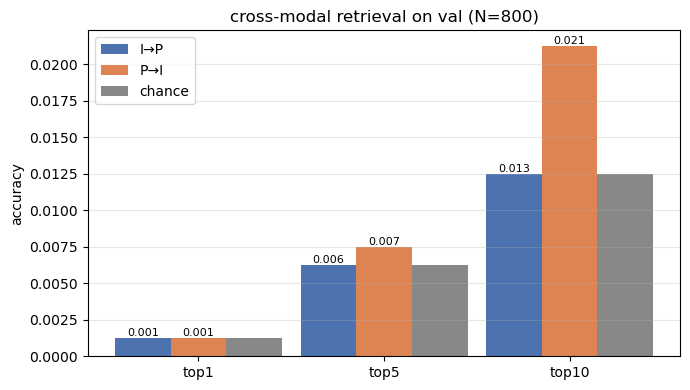

In [ ]:

@torch.no_grad()
def encode_val_modalities(model, ds, batch_size=None):
    """Encode each val scene from image-only and LiDAR-only views."""
    if batch_size is None:
        batch_size = CFG['train']['batch_size']
    model.eval()
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                         num_workers=CFG['train']['num_workers'],
                         pin_memory=CFG['train']['pin_memory'],
                         persistent_workers=CFG['train']['persistent_workers'],
                         collate_fn=collate)
    z_image, z_lidar = [], []
    for batch in tqdm(loader, desc='encode val'):
        img = batch['image'].to(device, non_blocking=True)
        pts = batch['points'].to(device, non_blocking=True)
        P2  = batch['P2'].to(device, non_blocking=True)
        Tr  = batch['Tr'].to(device, non_blocking=True)
        dino = img_encoder(img)
        occ, feat = voxelize_with_feats(
            pts, dino, P2, Tr, GRID,
            tuple(CFG['data']['voxel_resolution']),
            CFG['data']['image_size'], img_encoder.patch_grid)
        h_img = model.encode(torch.zeros_like(occ), feat, mask=None)
        h_lid = model.encode(occ, torch.zeros_like(feat), mask=None)
        z_image.append(h_img.mean(dim=(2, 3, 4)).cpu())
        z_lidar.append(h_lid.mean(dim=(2, 3, 4)).cpu())
    return torch.cat(z_image, 0), torch.cat(z_lidar, 0)


def retrieval_metrics(ZI, ZP):
    ZI_n = F.normalize(ZI, dim=-1)
    ZP_n = F.normalize(ZP, dim=-1)
    sim_IP = ZI_n @ ZP_n.t()
    sim_PI = ZP_n @ ZI_n.t()
    N = sim_IP.shape[0]
    gt = torch.arange(N).unsqueeze(-1)

    def topk(sim, k):
        return ((sim.topk(k, dim=-1).indices == gt).any(dim=-1).float().mean()).item()

    def medrank(sim):
        order = sim.argsort(dim=-1, descending=True)
        rank = (order == gt).int().argmax(dim=-1).float()
        return rank.median().item()

    out = {'N': N}
    for name, sim in [('I_to_P', sim_IP), ('P_to_I', sim_PI)]:
        out[name] = {
            'top1':    topk(sim, 1),
            'top5':    topk(sim, 5),
            'top10':   topk(sim, 10),
            'medrank': medrank(sim),
            'chance_top1': 1.0 / N,
            'chance_top5': 5.0 / N,
        }
    return out


retr_summary = None
if (OUT_BASE / 'full' / 'ckpt.pt').exists():
    ck = torch.load(OUT_BASE / 'full' / 'ckpt.pt', map_location=device,
                     weights_only=False)
    model_retr = OMUMAE(image_feat_dim=img_encoder.embed_dim,
                         hidden=CFG['model']['feat_dim']).to(device)
    model_retr.load_state_dict(ck['model'])

    ZI, ZP = encode_val_modalities(model_retr, val_ds)
    retr_summary = retrieval_metrics(ZI, ZP)
    print('\n=== Cross-modal retrieval (val, full variant) ===')
    for d in ('I_to_P', 'P_to_I'):
        r = retr_summary[d]
        print(f'  {d}:  top1={r["top1"]:.4f}  top5={r["top5"]:.4f}  '
              f'top10={r["top10"]:.4f}  medrank={r["medrank"]:.0f}  '
              f'(chance_top1={r["chance_top1"]:.4f})')

    # Bar chart
    fig, ax = plt.subplots(figsize=(7, 4))
    labels = ['top1', 'top5', 'top10']
    width = 0.3
    xs = np.arange(len(labels))
    ip_vals = [retr_summary['I_to_P'][k] for k in labels]
    pi_vals = [retr_summary['P_to_I'][k] for k in labels]
    chance = [retr_summary['I_to_P']['chance_top1'],
               retr_summary['I_to_P']['chance_top5'],
               retr_summary['I_to_P']['chance_top5'] * 2]
    ax.bar(xs - width, ip_vals, width, label='I→P', color='#4c72b0')
    ax.bar(xs,         pi_vals, width, label='P→I', color='#dd8452')
    ax.bar(xs + width, chance,  width, label='chance', color='#888')
    for i, (a, b) in enumerate(zip(ip_vals, pi_vals)):
        ax.text(i - width, a, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(i,         b, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels(labels)
    ax.set_ylabel('accuracy'); ax.set_title(f'cross-modal retrieval on val (N={retr_summary["N"]})')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(OUT_BASE / 'retrieval_full.png', dpi=120, bbox_inches='tight')
    plt.show()

    del model_retr
    if IS_CUDA:
        torch.cuda.empty_cache()
else:
    print('[skip] full variant checkpoint not found.')


## 15. Loss curves per variant


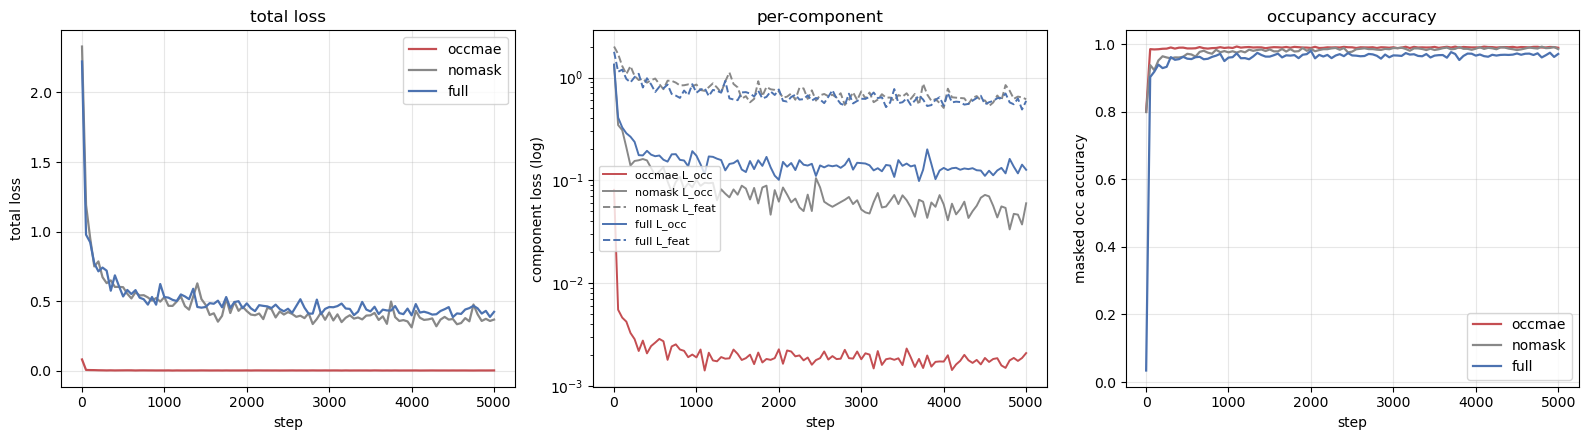

In [ ]:

import pandas as pd
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'occmae': '#c44e52', 'nomask': '#888888', 'full': '#4c72b0'}

for v in ['occmae', 'nomask', 'full']:
    csv_path = OUT_BASE / v / 'loss_log.csv'
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    axes[0].plot(df['step'], df['total'], label=v, color=colors[v], linewidth=1.6)
    axes[1].semilogy(df['step'], df['L_occ'], label=f'{v} L_occ',
                      color=colors[v], linewidth=1.4)
    if v != 'occmae':
        axes[1].semilogy(df['step'], df['L_feat'], label=f'{v} L_feat',
                          color=colors[v], linestyle='--', linewidth=1.4)
    axes[2].plot(df['step'], df['occ_acc'], label=v, color=colors[v], linewidth=1.6)

axes[0].set_xlabel('step'); axes[0].set_ylabel('total loss')
axes[0].set_title('total loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('step'); axes[1].set_ylabel('component loss (log)')
axes[1].set_title('per-component'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[2].set_xlabel('step'); axes[2].set_ylabel('masked occ accuracy')
axes[2].set_title('occupancy accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_BASE / 'loss_curves.png', dpi=130, bbox_inches='tight')
plt.show()


## 14. SemanticKITTI linear probe (4-way comparison)

Same protocol as v1: frozen encoder + 1×1×1 conv probe head, swept over
{1%, 5%, 10%, 100%} label fractions.  Run for each of the 4 variants.


In [ ]:

SK_LEARNING_MAP = {
    0:0, 1:0, 10:1, 11:2, 13:5, 15:3, 16:5, 18:4, 20:5,
    30:6, 31:7, 32:8, 40:9, 44:10, 48:11, 49:12, 50:13,
    51:14, 52:0, 60:9, 70:15, 71:16, 72:17, 80:18, 81:19,
    99:0, 252:1, 253:7, 254:6, 255:8, 256:5, 257:5, 258:4, 259:5,
}
NUM_CLASSES = 20
CLASS_NAMES = ['ignore', 'car', 'bicycle', 'motorcycle', 'truck', 'other-vehicle',
                'person', 'bicyclist', 'motorcyclist', 'road', 'parking', 'sidewalk',
                'other-ground', 'building', 'fence', 'vegetation', 'trunk', 'terrain',
                'pole', 'traffic-sign']

def remap_labels(raw_label_arr):
    sem = (raw_label_arr & 0xFFFF).astype(np.int32)
    out = np.zeros_like(sem)
    for k, v in SK_LEARNING_MAP.items():
        out[sem == k] = v
    return out

def voxelize_labels(points, raw_labels, grid_size, voxel_size):
    N = points.shape[0]
    X, Y, Z = grid_size
    vx, vy, vz = voxel_size
    ox = X * vx / 2; oy = Y * vy / 2; oz = Z * vz / 2

    sem = remap_labels(raw_labels)
    valid = sem > 0

    ix = np.clip(((points[:, 0] + ox) / vx).astype(np.int32), 0, X - 1)
    iy = np.clip(((points[:, 1] + oy) / vy).astype(np.int32), 0, Y - 1)
    iz = np.clip(((points[:, 2] + oz) / vz).astype(np.int32), 0, Z - 1)

    out = np.zeros((X, Y, Z), dtype=np.int32)
    counts = np.zeros((X, Y, Z, NUM_CLASSES), dtype=np.int32)
    for n in range(N):
        if not valid[n]:
            continue
        counts[ix[n], iy[n], iz[n], sem[n]] += 1
    has_any = counts.sum(axis=-1) > 0
    out[has_any] = counts[has_any].argmax(axis=-1)
    return out


labeled_samples = [s for s in samples if s.get('label') is not None]
if not labeled_samples:
    raise RuntimeError('No SemanticKITTI .label files matched. Check data paths.')

n_val_lab = max(64, len(labeled_samples) // 10)
train_lab = labeled_samples[:-n_val_lab]
val_lab   = labeled_samples[-n_val_lab:]
print(f'samples with labels: {len(labeled_samples)} / {len(samples)}')
print(f'probe train: {len(train_lab)}  probe val: {len(val_lab)}')


samples with labels: 4302 / 8000
probe train: 3872  probe val: 430


In [ ]:

class LabeledKitti(Dataset):
    def __init__(self, samples, calib_cache, image_size=224, n_points=16384):
        self.samples = samples; self.calib_cache = calib_cache
        self.image_size = image_size; self.n_points = n_points

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_pil = Image.open(s['img']).convert('RGB')
        W_orig, H_orig = img_pil.size
        img_pil = img_pil.resize((self.image_size, self.image_size))
        img = np.asarray(img_pil).astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std
        img = np.transpose(img, (2, 0, 1))

        pts = np.fromfile(s['bin'], dtype=np.float32).reshape(-1, 4)
        raw_labels = np.fromfile(s['label'], dtype=np.uint32)
        if pts.shape[0] >= self.n_points:
            sel = np.random.choice(pts.shape[0], self.n_points, replace=False)
            pts = pts[sel]; raw_labels = raw_labels[sel]
        else:
            pad = np.zeros((self.n_points - pts.shape[0], 4), dtype=np.float32)
            pts = np.concatenate([pts, pad], axis=0)
            raw_labels = np.concatenate(
                [raw_labels, np.zeros(self.n_points - len(raw_labels), dtype=np.uint32)])

        cal = self.calib_cache[s['seq']]
        sx = self.image_size / W_orig; sy = self.image_size / H_orig
        S = np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], dtype=np.float32)
        P2_scaled = (S @ cal['P2']).astype(np.float32)
        Tr = cal['Tr'].astype(np.float32)

        vox_lbl = voxelize_labels(pts, raw_labels, GRID,
                                    tuple(CFG['data']['voxel_resolution']))

        return {
            'image':   torch.from_numpy(img.astype(np.float32)),
            'points':  torch.from_numpy(pts),
            'P2':      torch.from_numpy(P2_scaled),
            'Tr':      torch.from_numpy(Tr),
            'vox_lbl': torch.from_numpy(vox_lbl).long(),
        }

def collate_lab(batch):
    return {
        'image':   torch.stack([b['image']   for b in batch]),
        'points':  torch.stack([b['points']  for b in batch]),
        'P2':      torch.stack([b['P2']      for b in batch]),
        'Tr':      torch.stack([b['Tr']      for b in batch]),
        'vox_lbl': torch.stack([b['vox_lbl'] for b in batch]),
    }


class ProbeHead(nn.Module):
    def __init__(self, in_dim, num_classes=NUM_CLASSES, target_grid=GRID):
        super().__init__()
        self.classifier = nn.Conv3d(in_dim, num_classes, 1)
        self.target_grid = target_grid

    def forward(self, h):
        logits = self.classifier(h)
        logits = F.interpolate(logits, size=self.target_grid,
                                mode='trilinear', align_corners=False)
        return logits


@torch.no_grad()
def encoder_features(model, image, points, P2, Tr, use_dinov2):
    if use_dinov2:
        dino = img_encoder(image)
        occ, feat = voxelize_with_feats(
            points, dino, P2, Tr, GRID,
            tuple(CFG['data']['voxel_resolution']),
            CFG['data']['image_size'], img_encoder.patch_grid)
        return model.encode(occ, feat, mask=None)
    else:
        occ = voxelize_lidar_only(points, GRID,
                                    tuple(CFG['data']['voxel_resolution']))
        return model.encode(occ, mask=None)


def train_probe(model, head, train_set, val_set, use_dinov2, n_epochs=5,
                lr=5e-3, batch_size=None, label_fraction=1.0):
    if batch_size is None:
        batch_size = CFG['train']['batch_size']

    if label_fraction < 1.0:
        n = max(1, int(len(train_set) * label_fraction))
        train_subset = Subset(train_set,
                                np.random.RandomState(SEED).choice(len(train_set), n,
                                                                    replace=False))
    else:
        train_subset = train_set

    loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                         num_workers=CFG['train']['num_workers'],
                         pin_memory=CFG['train']['pin_memory'],
                         persistent_workers=CFG['train']['persistent_workers'],
                         collate_fn=collate_lab,
                         generator=seed_generator,
                         worker_init_fn=seed_worker if CFG['train']['num_workers'] > 0 else None)
    opt_p = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)

    model.eval(); head.train()
    for epoch in range(n_epochs):
        running = 0.0; n = 0
        for batch in tqdm(loader, desc=f'  probe ep{epoch+1}/{n_epochs} f={label_fraction*100:.0f}%',
                          leave=False):
            img = batch['image'].to(device, non_blocking=True)
            pts = batch['points'].to(device, non_blocking=True)
            P2 = batch['P2'].to(device, non_blocking=True)
            Tr = batch['Tr'].to(device, non_blocking=True)
            lbl = batch['vox_lbl'].to(device, non_blocking=True)
            with torch.no_grad():
                h = encoder_features(model, img, pts, P2, Tr, use_dinov2)
            logits = head(h)
            loss = F.cross_entropy(logits, lbl, ignore_index=0)
            opt_p.zero_grad(); loss.backward(); opt_p.step()
            running += loss.item(); n += 1
        print(f'    epoch {epoch+1}: ce_loss={running/max(n,1):.4f}')


@torch.no_grad()
def evaluate_probe(model, head, val_set, use_dinov2, batch_size=None):
    if batch_size is None:
        batch_size = CFG['train']['batch_size']
    model.eval(); head.eval()
    loader = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                         num_workers=CFG['train']['num_workers'],
                         pin_memory=CFG['train']['pin_memory'],
                         persistent_workers=CFG['train']['persistent_workers'],
                         collate_fn=collate_lab)
    intersect = np.zeros(NUM_CLASSES, dtype=np.int64)
    union     = np.zeros(NUM_CLASSES, dtype=np.int64)
    for batch in tqdm(loader, desc='  eval', leave=False):
        img = batch['image'].to(device, non_blocking=True)
        pts = batch['points'].to(device, non_blocking=True)
        P2  = batch['P2'].to(device, non_blocking=True)
        Tr  = batch['Tr'].to(device, non_blocking=True)
        lbl = batch['vox_lbl'].to(device, non_blocking=True)
        h = encoder_features(model, img, pts, P2, Tr, use_dinov2)
        logits = head(h)
        pred = logits.argmax(dim=1)
        valid = lbl > 0
        for c in range(1, NUM_CLASSES):
            p = (pred == c) & valid
            t = (lbl == c) & valid
            intersect[c] += (p & t).sum().item()
            union[c]     += (p | t).sum().item()
    iou = intersect / np.clip(union, 1, None)
    miou = iou[1:].mean()
    return float(miou), iou


In [ ]:

train_lab_set = LabeledKitti(train_lab, calib_cache,
                              CFG['data']['image_size'], CFG['data']['n_points'])
val_lab_set   = LabeledKitti(val_lab,   calib_cache,
                              CFG['data']['image_size'], CFG['data']['n_points'])

H_DIM = CFG['model']['feat_dim'] * 4
print(f'encoder bottleneck dim: {H_DIM}')

PROBE_EPOCHS = 5
PROBE_LR = 5e-3
label_fractions = [0.01, 0.05, 0.10, 1.00]


@torch.no_grad()
def collect_predictions(model, head, val_set, use_dinov2, batch_size=None):
    """Run probe over val set; return concatenated (preds, labels) at masked-occ voxels."""
    if batch_size is None:
        batch_size = CFG['train']['batch_size']
    model.eval(); head.eval()
    loader = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                         num_workers=CFG['train']['num_workers'],
                         pin_memory=CFG['train']['pin_memory'],
                         persistent_workers=CFG['train']['persistent_workers'],
                         collate_fn=collate_lab)
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc='  collect preds', leave=False):
        img = batch['image'].to(device, non_blocking=True)
        pts = batch['points'].to(device, non_blocking=True)
        P2  = batch['P2'].to(device, non_blocking=True)
        Tr  = batch['Tr'].to(device, non_blocking=True)
        lbl = batch['vox_lbl'].to(device, non_blocking=True)
        h = encoder_features(model, img, pts, P2, Tr, use_dinov2)
        pred = head(h).argmax(dim=1)
        valid = lbl > 0
        all_preds.append(pred[valid].cpu().numpy())
        all_labels.append(lbl[valid].cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def normalized_confusion(preds, labels, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(cm, (labels, preds), 1)
    row = cm.sum(axis=1, keepdims=True).clip(min=1)
    return cm / row


results = {v: {} for v in VARIANTS}
confusion_matrices = {}

for variant in VARIANTS:
    print(f'\n{"="*70}\nProbing variant: {variant}\n{"="*70}')
    vcfg = VARIANTS[variant]

    # Load encoder for this variant
    model = make_model(variant)
    if vcfg['pretrain']:
        ck = torch.load(OUT_BASE / variant / 'ckpt.pt', map_location=device,
                         weights_only=False)
        model.load_state_dict(ck['model'])
        print(f'  loaded pretrained ckpt')
    else:
        print(f'  using fresh random init (no pretraining)')

    use_dino = vcfg['use_dinov2_input']

    for frac in label_fractions:
        print(f'\n  ----- label fraction = {frac*100:.0f}% -----')
        head = ProbeHead(H_DIM, NUM_CLASSES, GRID).to(device)
        train_probe(model, head, train_lab_set, val_lab_set, use_dino,
                     n_epochs=PROBE_EPOCHS, lr=PROBE_LR,
                     batch_size=CFG['train']['batch_size'],
                     label_fraction=frac)
        miou, iou = evaluate_probe(model, head, val_lab_set, use_dino,
                                     batch_size=CFG['train']['batch_size'])
        results[variant][frac] = {'miou': miou, 'iou_per_class': iou.tolist()}
        print(f'    {variant} mIoU @ {frac*100:.0f}%: {miou*100:.2f}%')

        # At 100% labels, also collect the confusion matrix
        if frac == 1.00:
            print(f'  collecting confusion matrix for {variant} @ 100%...')
            preds, lbls = collect_predictions(model, head, val_lab_set, use_dino,
                                               batch_size=CFG['train']['batch_size'])
            cm = normalized_confusion(preds, lbls, NUM_CLASSES)
            confusion_matrices[variant] = cm

    del model
    if IS_CUDA:
        torch.cuda.empty_cache()

with open(OUT_BASE / 'probe_results.json', 'w') as f:
    json.dump(results, f, indent=2)
np.savez(OUT_BASE / 'confusion_matrices.npz',
          **{f'cm_{v}': confusion_matrices[v] for v in confusion_matrices},
          class_names=np.array(CLASS_NAMES))
print(f'\nsaved -> {OUT_BASE / "probe_results.json"}')
print(f'saved -> {OUT_BASE / "confusion_matrices.npz"}')


NameError: name 'LabeledKitti' is not defined

## 15. 4-way comparison (random / occmae / nomask / full)



=== mIoU summary table ===
 label %    random    occmae    nomask      full
      1%     4.89%     8.66%     9.24%    10.78%
      5%     5.56%    11.55%    11.01%    13.20%
     10%     5.25%    11.96%    11.46%    14.13%
    100%     5.32%    14.31%    14.24%    15.74%


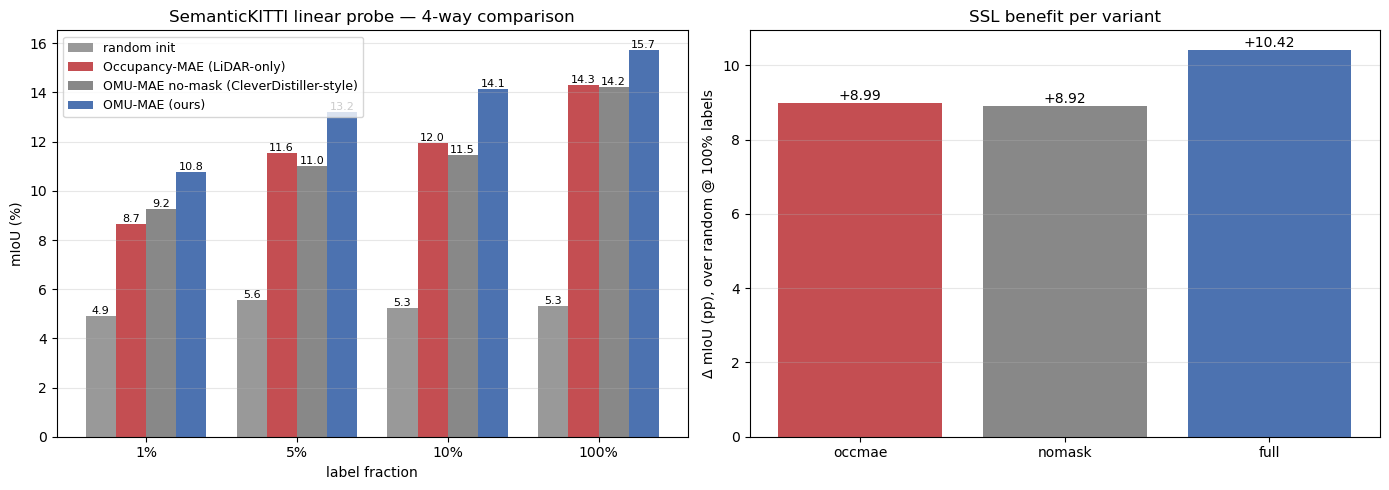

In [ ]:

fracs = label_fractions
miou_table = {v: [results[v][f]['miou'] * 100 for f in fracs] for v in VARIANTS}

print('\n=== mIoU summary table ===')
print(f'{"label %":>8s}', end='')
for v in VARIANTS:
    print(f'  {v:>8s}', end='')
print()
for i, f in enumerate(fracs):
    print(f'{f*100:>7.0f}%', end='')
    for v in VARIANTS:
        print(f'  {miou_table[v][i]:>7.2f}%', end='')
    print()

# headline plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(fracs))
w = 0.2
colors = {'random': '#999', 'occmae': '#c44e52', 'nomask': '#888',
          'full':   '#4c72b0'}
labels = {'random': 'random init', 'occmae': 'Occupancy-MAE (LiDAR-only)',
          'nomask': 'OMU-MAE no-mask (CleverDistiller-style)',
          'full':   'OMU-MAE (ours)'}

# Left: grouped bars
for j, v in enumerate(['random', 'occmae', 'nomask', 'full']):
    offsets = (j - 1.5) * w
    bars = axes[0].bar(x + offsets, miou_table[v], w, label=labels[v],
                        color=colors[v])
    for i, b in enumerate(bars):
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height(),
                       f'{miou_table[v][i]:.1f}',
                       ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{f*100:.0f}%' for f in fracs])
axes[0].set_xlabel('label fraction'); axes[0].set_ylabel('mIoU (%)')
axes[0].set_title('SemanticKITTI linear probe — 4-way comparison')
axes[0].legend(loc='upper left', fontsize=9); axes[0].grid(alpha=0.3, axis='y')

# Right: Δ over random for each pretrained variant at 100% labels
deltas_100 = {v: miou_table[v][-1] - miou_table['random'][-1]
                for v in ['occmae', 'nomask', 'full']}
xs = np.arange(len(deltas_100))
bars = axes[1].bar(xs, list(deltas_100.values()),
                     color=[colors[v] for v in deltas_100])
axes[1].set_xticks(xs); axes[1].set_xticklabels(list(deltas_100.keys()))
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Δ mIoU (pp), over random @ 100% labels')
axes[1].set_title('SSL benefit per variant')
axes[1].grid(alpha=0.3, axis='y')
for i, (k, v) in enumerate(deltas_100.items()):
    axes[1].text(i, v, f'{v:+.2f}', ha='center',
                   va='bottom' if v >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_BASE / 'probe_comparison_4way.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Per-class IoU at 100% labels (4-way)

Which classes does each pretraining strategy help most? Sorted by full-OMU-MAE
IoU; per-class Δ vs. random shown on the right.


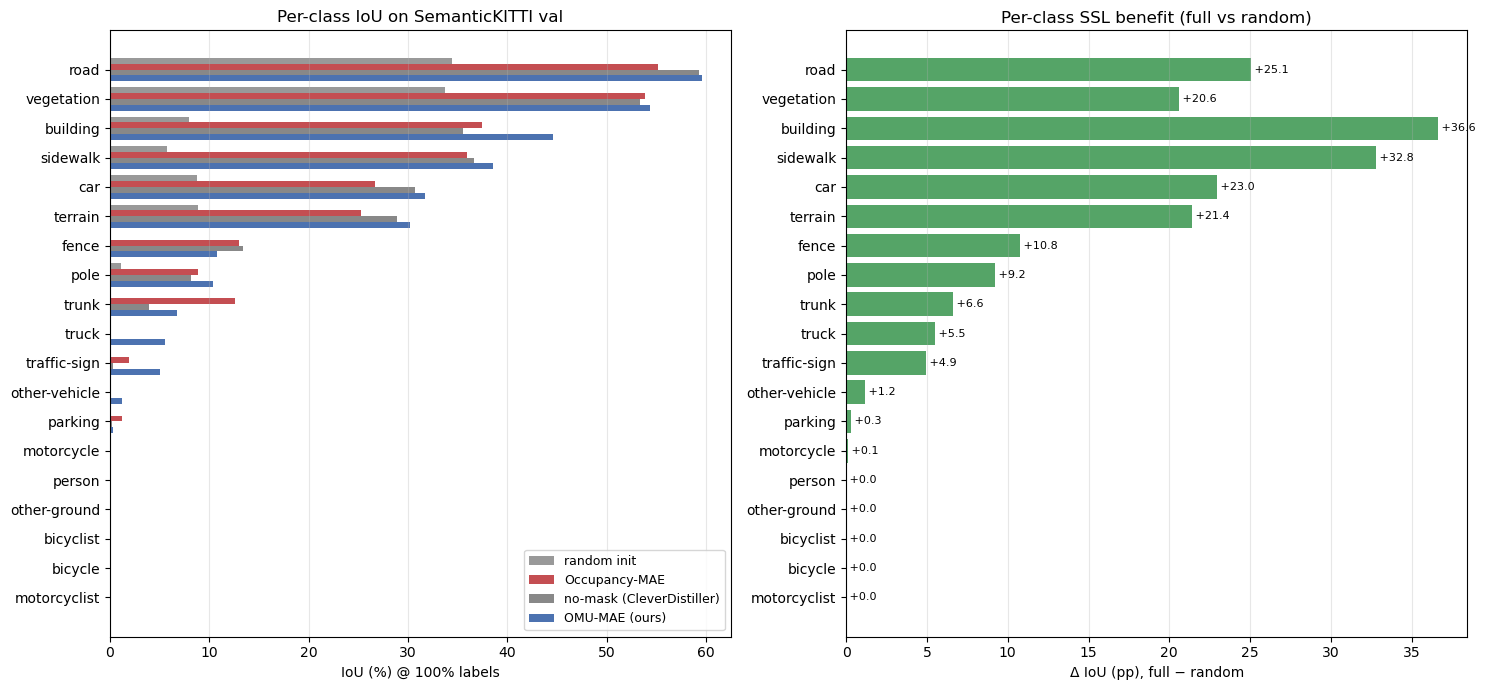

In [ ]:

iou_100 = {v: np.array(results[v][1.0]['iou_per_class']) * 100 for v in VARIANTS}

# Rank by full-OMU-MAE IoU (descending), excluding ignore class
valid_idx = np.arange(1, NUM_CLASSES)
order = valid_idx[np.argsort(-iou_100['full'][1:])]
names = [CLASS_NAMES[i] for i in order]

# Left: per-class IoU bars (4 variants)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
y = np.arange(len(order))
bh = 0.2
colors = {'random': '#999', 'occmae': '#c44e52', 'nomask': '#888',
          'full':   '#4c72b0'}
labels = {'random': 'random init', 'occmae': 'Occupancy-MAE',
          'nomask': 'no-mask (CleverDistiller)', 'full': 'OMU-MAE (ours)'}

for j, v in enumerate(['random', 'occmae', 'nomask', 'full']):
    offset = (j - 1.5) * bh
    axes[0].barh(y + offset, iou_100[v][order], bh, label=labels[v],
                  color=colors[v])
axes[0].set_yticks(y); axes[0].set_yticklabels(names)
axes[0].invert_yaxis()
axes[0].set_xlabel('IoU (%) @ 100% labels')
axes[0].set_title('Per-class IoU on SemanticKITTI val')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(alpha=0.3, axis='x')

# Right: per-class Δ (full - random)
delta_per_class = iou_100['full'][order] - iou_100['random'][order]
bar_colors = ['#55a467' if d > 0 else '#c44e52' for d in delta_per_class]
axes[1].barh(y, delta_per_class, color=bar_colors)
axes[1].set_yticks(y); axes[1].set_yticklabels(names)
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Δ IoU (pp), full − random')
axes[1].set_title('Per-class SSL benefit (full vs random)')
axes[1].grid(alpha=0.3, axis='x')
for i, d in enumerate(delta_per_class):
    axes[1].text(d, i, f' {d:+.1f}', va='center',
                   ha='left' if d >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_BASE / 'probe_per_class_iou.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Confusion matrices at 100% labels (4-way)

Row-normalized confusion matrices for each pretraining variant. Stronger
diagonal structure indicates better class disambiguation.


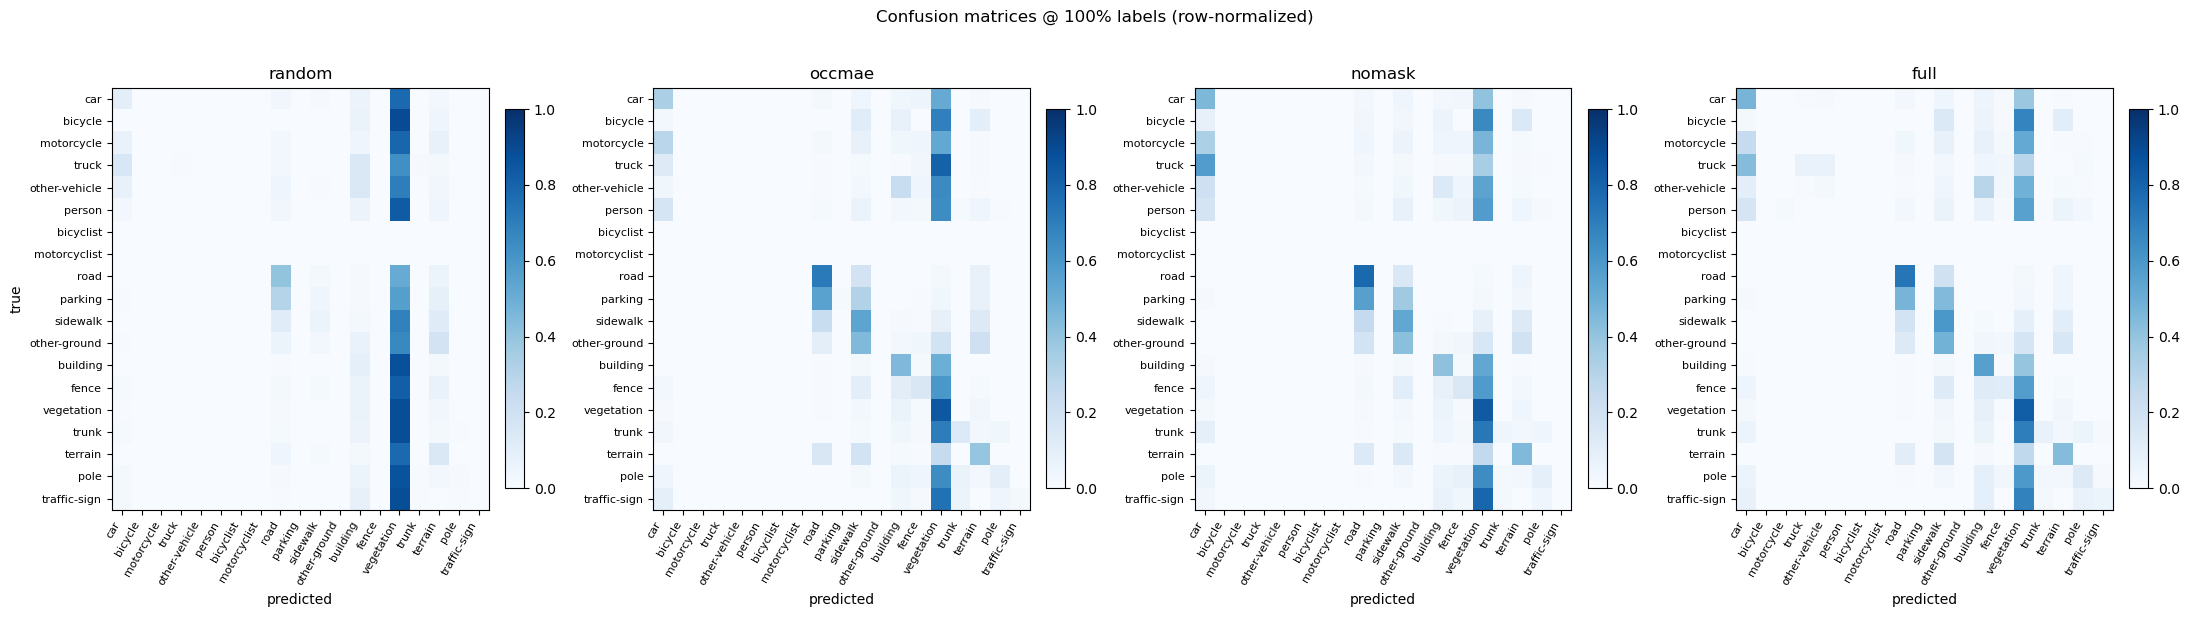

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
labels_short = [CLASS_NAMES[i] for i in range(1, NUM_CLASSES)]

for ax, variant in zip(axes, ['random', 'occmae', 'nomask', 'full']):
    cm = confusion_matrices[variant][1:, 1:]
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(np.arange(len(labels_short)))
    ax.set_xticklabels(labels_short, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(np.arange(len(labels_short)))
    ax.set_yticklabels(labels_short, fontsize=8)
    ax.set_xlabel('predicted'); ax.set_ylabel('true' if variant == 'random' else '')
    ax.set_title(f'{variant}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confusion matrices @ 100% labels (row-normalized)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_BASE / 'probe_confusion_4way.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

final = {
    'method': 'OMU-MAE-full-comparison',
    'variants': {v: VARIANTS[v] for v in VARIANTS},
    'probe_label_fractions': fracs,
    'probe_miou_pct': miou_table,
    'class_names': CLASS_NAMES,
    'probe_per_class_iou_at_100pct': {
        v: results[v][1.0]['iou_per_class'] for v in VARIANTS},
    'retrieval_full': retr_summary,
    'cfg': CFG,
}
with open(OUT_BASE / 'final_results.json', 'w') as f:
    json.dump(final, f, indent=2)
print(f'\nSaved final results -> {OUT_BASE / "final_results.json"}')
print(f'Saved figures:')
for fname in ['loss_curves.png', 'reconstruction_full.png', 'retrieval_full.png',
                'probe_comparison_4way.png', 'probe_per_class_iou.png',
                'probe_confusion_4way.png']:
    p = OUT_BASE / fname
    if p.exists():
        print(f'  - {p}')
print('\nDone. Full ablation suite ready for the paper.')


NameError: name 'VARIANTS' is not defined